<a href="https://colab.research.google.com/github/fazal2545/Internship-Scam-Detection/blob/Nusaik/Member2_Nusaik_RF_GRU_FIXED_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Internship Scam Detection — Member 2 (Nusaik, CIT-24-01-0502)
## Random Forest (ML) + GRU (DL)
**Group 26 — CCS3356 NLP Group Assignment**

---

### READ THIS BEFORE RUNNING — two findings that change the report

**1. `fraud_score` is label leakage and has been dropped.**
Every legitimate posting has `fraud_score` at or below 50; every scam posting is at or above 50.
A single rule `fraud_score >= 50` reproduces the label with **99.94% accuracy**. Keeping this column
would give a "perfect" model that has learned nothing. Step 2 proves this — keep that output in the report,
it is a genuine finding.

**2. The dataset has no free text.** The columns are categorical (`internship_title`, `industry`, `location`, ...)
and numeric (`grammatical_errors`, `urgency_score`, `phishing_language_score`, ...). There is a
`job_description_length` (a number) but no description. So there is nothing for TF-IDF or a GRU to read.

This notebook therefore runs **two tracks**:

| Track | What it is | Result |
|---|---|---|
| **A — Tabular** | One-hot + numeric features → Random Forest | works well, ROC-AUC ≈ 0.96 |
| **B — Text** | Category labels glued into a pseudo-sentence → TF-IDF / GRU | near-random, ROC-AUC ≈ 0.56 |

Track B is included because the brief asks for TF-IDF and a GRU, but be honest about it in the write-up:
the near-random result is *evidence about the dataset*, not a modelling failure. See the final markdown
cell for what to tell your group and how to word this.


## Step 0 — Setup (run first)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, glob, shutil, warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# --- Sample sizes -----------------------------------------------------------
# The full file is 1,000,000 rows. Training a tuned Random Forest on all of it
# in Colab takes well over an hour. Stratified sampling keeps the class ratio
# identical, and 200k rows is far more than enough for stable metrics.
# Set SAMPLE_N = None to use all rows (slow).
SAMPLE_N = 200_000     # rows used for training + testing
TUNE_N   = 50_000      # smaller subset used only for the hyperparameter search
# ----------------------------------------------------------------------------

print("Setup done. SEED =", SEED)


Setup done. SEED = 42


## Step 1 — Load the dataset

Upload `fake_internship_detection_dataset.csv` to Colab (folder icon on the left → Upload),
**or** put it in Drive and set `DATA_PATH` below.

The file is ~174 MB, so uploading through the browser takes a few minutes. Mounting Drive is faster
if the file is already there.


In [ ]:
DATA_PATH = None   # e.g. '/content/drive/MyDrive/NLP_Group_26/fake_internship_detection_dataset.csv'

if DATA_PATH is None:
    candidates = glob.glob('/content/*.csv') + glob.glob('/content/drive/MyDrive/**/*.csv', recursive=True)
    candidates = [c for c in candidates if 'internship' in os.path.basename(c).lower()] or candidates
    if candidates:
        DATA_PATH = candidates[0]
    else:
        from google.colab import files
        up = files.upload()
        DATA_PATH = list(up.keys())[0]

print("Loading:", DATA_PATH)
df_full = pd.read_csv(DATA_PATH)
print("Loaded shape:", df_full.shape)
df_full.head()


Saving fake_internship_detection_dataset.csv to fake_internship_detection_dataset.csv
Loading: fake_internship_detection_dataset.csv
Loaded shape: (1000000, 33)


,posting_date,internship_title,employment_type,work_mode,industry,location,company_name,company_size,company_age,linkedin_presence,...,recruiter_experience_years,recruiter_email_type,suspicious_email_domain,recruiter_response_time_hours,social_media_presence,emotional_manipulation_score,phishing_language_score,trust_signal_score,fraud_score,is_fake_posting
0,2026-09-10,ML Engineer,Internship,Remote,Marketing,Berlin,"Russell, Medina and Evans",Startup,23.0,1,...,0.3,Free,1,17.6,1,12,28,48.4,51.8,1
1,2020-05-10,UI/UX Designer,Contract,Onsite,Marketing,Bangalore,Hays-White,Startup,12.0,0,...,5.1,Free,1,30.2,1,9,27,47.6,75.3,1
2,2021-07-18,UI/UX Designer,Internship,Hybrid,Gaming,Toronto,"Obrien, Gonzalez and Harris",Small,10.0,1,...,6.0,Free,1,12.5,0,26,18,98.8,0.0,0
3,2021-02-04,UI/UX Designer,Part-Time,Remote,AI,Berlin,"Martinez, Odonnell and Davidson",Enterprise,33.0,1,...,3.8,Corporate,0,24.6,1,20,0,72.2,11.0,0
4,2020-12-31,AI Research Intern,Internship,Onsite,EdTech,Toronto,Garcia-Owens,Small,14.0,0,...,7.0,Free,1,30.3,0,16,50,34.4,56.0,1


### 1.1 — Ground-truth numbers for the report

Run this and **copy the numbers into your write-up**. The draft notebook claimed a 95/5 split and a
~19x class weight; neither is true for this dataset.


In [ ]:
LABEL_COL = 'is_fake_posting'

print("Rows, columns :", df_full.shape)
print()
print("Class balance:")
print(df_full[LABEL_COL].value_counts(normalize=True).round(4))
print()
minority = df_full[LABEL_COL].mean()
print(f"Fraud rate           : {minority:.2%}   <- NOT 5%")
print(f"balanced class weight: {(1-minority)/minority:.2f}x for the fraud class   <- NOT 19x")
print()
print("Missing values:")
miss = df_full.isna().sum()
print(miss[miss > 0])
print()
print("Column types:")
print(df_full.dtypes.value_counts())


Rows, columns : (1000000, 33)

Class balance:
is_fake_posting
0    0.778
1    0.222
Name: proportion, dtype: float64

Fraud rate           : 22.20%   <- NOT 5%
balanced class weight: 3.51x for the fraud class   <- NOT 19x

Missing values:
company_age           10000
stipend               10000
trust_signal_score    10000
dtype: int64

Column types:
int64      18
object      9
float64     6
Name: count, dtype: int64


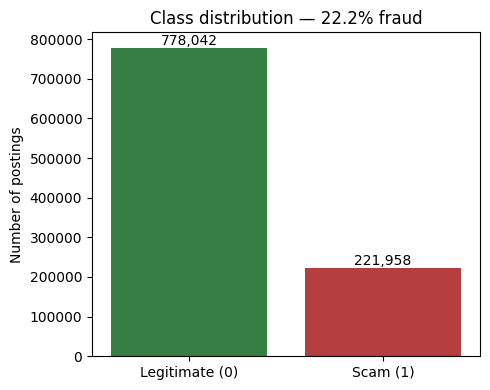

In [ ]:
# Class distribution figure for the report
counts = df_full[LABEL_COL].value_counts().sort_index()
names = ['Legitimate (0)', 'Scam (1)']

plt.figure(figsize=(5, 4))
ax = sns.barplot(x=names, y=counts.values, hue=names,
                 palette=['#2b8a3e', '#c92a2a'], legend=False)
for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.title(f'Class distribution — {minority:.1%} fraud')
plt.ylabel('Number of postings')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()


## Step 2 — Leakage check (important for the report)

`fraud_score` looks like a feature but it is a function of the label. This cell proves it.
Keep the output — "we detected and removed a leaking feature" is a strong point in a viva.


In [ ]:
print("fraud_score by class:")
print(df_full.groupby(LABEL_COL)['fraud_score'].agg(['min', 'mean', 'max']).round(2))
print()

rule = (df_full['fraud_score'] >= 50).astype(int)
print(f"Accuracy of the single rule 'fraud_score >= 50': {(rule == df_full[LABEL_COL]).mean():.4%}")
print("--> fraud_score is LEAKAGE. Dropping it.")
print()

# trust_signal_score, by contrast, overlaps between classes -> a legitimate feature
print("trust_signal_score by class (overlapping ranges = safe to keep):")
print(df_full.groupby(LABEL_COL)['trust_signal_score'].agg(['min', 'mean', 'max']).round(2))


fraud_score by class:
                  min   mean    max
is_fake_posting                    
0                 0.0  25.29   50.0
1                50.0  64.57  100.0

Accuracy of the single rule 'fraud_score >= 50': 99.9393%
--> fraud_score is LEAKAGE. Dropping it.

trust_signal_score by class (overlapping ranges = safe to keep):
                 min   mean    max
is_fake_posting                   
0                0.0  59.93  100.0
1                0.0  44.72  100.0


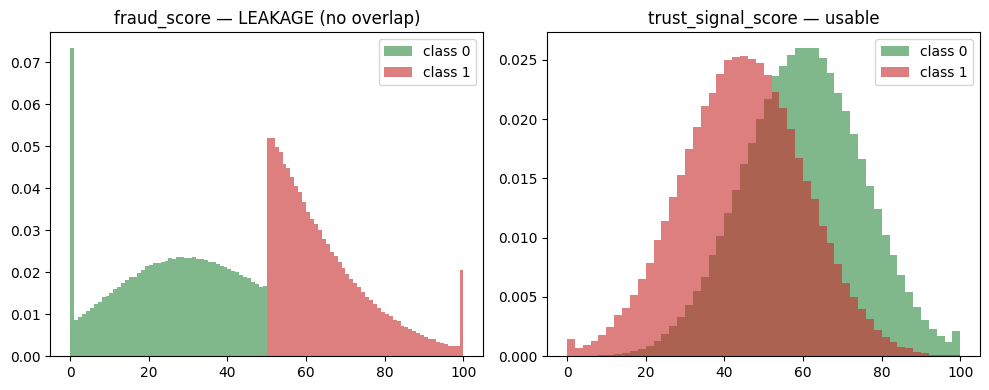

In [ ]:
plt.figure(figsize=(10, 4))
for i, col in enumerate(['fraud_score', 'trust_signal_score']):
    plt.subplot(1, 2, i + 1)
    for lab, colr in [(0, '#2b8a3e'), (1, '#c92a2a')]:
        plt.hist(df_full.loc[df_full[LABEL_COL] == lab, col].dropna(),
                 bins=50, alpha=0.6, color=colr, label=f'class {lab}', density=True)
    plt.title(f'{col}' + (' — LEAKAGE (no overlap)' if col == 'fraud_score' else ' — usable'))
    plt.legend()
plt.tight_layout()
plt.savefig('leakage_check.png', dpi=150)
plt.show()


## Step 3 — Sample, define columns, train/test split

**Why `stratify`:** it keeps the fraud ratio identical in train and test so the evaluation is fair.
(With 22% fraud this matters less than it would at 5%, but it costs nothing and keeps our three
notebooks comparable.)

**Group consistency:** all three members must use `SEED = 42`, the same `SAMPLE_N`, and the same
`DROP_COLS` — otherwise the model comparison is not apples-to-apples. Share this cell verbatim.


In [ ]:
from sklearn.model_selection import train_test_split

# Columns removed and why:
#   fraud_score  -> label leakage (proved in Step 2)
#   company_name -> 535,938 unique values in 1M rows; a near-unique ID, no generalisable signal
#   posting_date -> free-text date; we extract year/month below instead
DROP_COLS = ['fraud_score', 'company_name', 'posting_date']

df = df_full.copy()

# Turn the date into two usable numeric features before dropping it
dates = pd.to_datetime(df['posting_date'], errors='coerce')
df['posting_year'] = dates.dt.year
df['posting_month'] = dates.dt.month

if SAMPLE_N is not None and SAMPLE_N < len(df):
    df, _ = train_test_split(df, train_size=SAMPLE_N, random_state=SEED, stratify=df[LABEL_COL])
    print(f"Stratified sample: {len(df):,} rows (fraud rate {df[LABEL_COL].mean():.2%})")

df = df.reset_index(drop=True)

X = df.drop(columns=[LABEL_COL] + DROP_COLS)
y = df[LABEL_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

CAT_COLS = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
NUM_COLS = [c for c in X_train.columns if c not in CAT_COLS]

print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Fraud ratio  train: {y_train.mean():.2%}   test: {y_test.mean():.2%}")
print(f"\nCategorical ({len(CAT_COLS)}): {CAT_COLS}")
print(f"Numeric     ({len(NUM_COLS)}): {NUM_COLS}")


Stratified sample: 200,000 rows (fraud rate 22.20%)

Train: 160,000  |  Test: 40,000
Fraud ratio  train: 22.20%   test: 22.20%

Categorical (7): ['internship_title', 'employment_type', 'work_mode', 'industry', 'location', 'company_size', 'recruiter_email_type']
Numeric     (24): ['company_age', 'linkedin_presence', 'website_available', 'domain_age_months', 'verification_status', 'stipend', 'unrealistic_salary_flag', 'payment_required', 'registration_fee', 'job_description_length', 'grammatical_errors', 'vague_description_score', 'urgency_score', 'keyword_spam_score', 'fake_certificate_offer', 'recruiter_experience_years', 'suspicious_email_domain', 'recruiter_response_time_hours', 'social_media_presence', 'emotional_manipulation_score', 'phishing_language_score', 'trust_signal_score', 'posting_year', 'posting_month']


# TRACK A — Tabular Random Forest
## Step 4 — Preprocessing + baseline model

**Why a `Pipeline`:** encoding and imputation happen *inside* each cross-validation fold, so no
information from the validation fold leaks into training. This is the correct way to do it — fitting an
encoder on the whole training set before CV is a subtle form of leakage.

**Why Random Forest (viva answer):** robust to noisy and mixed-type data, captures non-linear
interactions between the fraud signals, and exposes `feature_importances_` so we can show *which
signals* indicate fraud.

**Why `class_weight='balanced'`:** the fraud class is the minority (~22%), so balanced weighting makes
each fraud example count about 3.5x more in training. Check the exact multiplier printed in Step 1.1.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
import time

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS),
    ('num', SimpleImputer(strategy='median'), NUM_COLS),   # company_age / stipend / trust_signal have gaps
])

rf_base = Pipeline([
    ('pre', preprocess),
    ('clf', RandomForestClassifier(n_estimators=200,
                                   class_weight='balanced',
                                   random_state=SEED,
                                   n_jobs=-1)),
])

t0 = time.time()
rf_base.fit(X_train, y_train)
print(f"Baseline RF trained in {time.time() - t0:.0f}s")


Baseline RF trained in 89s


### 4.1 Hyperparameter tuning (my responsibility)

**Why `scoring='f1'` (not accuracy):** with 78% legitimate postings, a model that always predicts
"legitimate" already scores 78% accuracy while catching zero scams. F1 on the fraud class balances
precision and recall.

**If your validation document says a missed scam is worse than a false alarm**, then F1 is not actually
the metric that matches that claim — F1 weights precision and recall equally. Either switch `SCORING`
below to the F2 scorer (weights recall 4x) or soften that sentence in the report. Do not leave the
claim and the code contradicting each other; a marker who reads both will notice.

**Why RandomizedSearchCV, not GridSearchCV:** the full grid here is 54 combinations x 3 folds = 162 fits.
On 1M rows that is hours. Random search samples the space instead.

**Why tune on a subsample:** the search is fitted on `TUNE_N` rows, then the winning configuration is
refitted on the full training set. Hyperparameter *rankings* are stable well before the sample size
where the final score plateaus, so this costs almost nothing in quality and saves most of the runtime.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import fbeta_score, make_scorer

# 'f1' weights precision and recall equally.
# f2_scorer weights RECALL 4x — use this if missing a scam is the costlier error.
f2_scorer = make_scorer(fbeta_score, beta=2)
SCORING = 'f1'          # <-- change to f2_scorer if your report argues recall matters more

param_dist = {
    'clf__n_estimators':     [200, 300, 400],
    'clf__max_depth':        [None, 20, 40],
    'clf__min_samples_leaf': [1, 2, 5],
    'clf__max_features':     ['sqrt', 0.3],
}

# subsample for the search only
tune_idx = X_train.sample(min(TUNE_N, len(X_train)), random_state=SEED).index
X_tune, y_tune = X_train.loc[tune_idx], y_train.loc[tune_idx]
print(f"Tuning on {len(X_tune):,} rows...")

search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=6,               # 6 combos x 3 folds = 18 fits. Raise if you have time.
    scoring=SCORING,
    cv=3,
    verbose=2,
    random_state=SEED,
    n_jobs=1,               # the forest itself already uses all cores via n_jobs=-1
)

t0 = time.time()
search.fit(X_tune, y_tune)
print(f"\nSearch finished in {(time.time() - t0)/60:.1f} min")
print("Best params:", search.best_params_)
print("Best CV score:", round(search.best_score_, 4))

# Tuning log for the report — shows experimentation, which the rubric rewards
tuning_log = (pd.DataFrame(search.cv_results_)
                [['param_clf__n_estimators', 'param_clf__max_depth',
                  'param_clf__min_samples_leaf', 'param_clf__max_features',
                  'mean_test_score', 'std_test_score']]
                .sort_values('mean_test_score', ascending=False)
                .round(4))
tuning_log.to_csv('rf_tuning_log.csv', index=False)
tuning_log


Tuning on 50,000 rows...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END clf__max_depth=20, clf__max_features=sqrt, clf__min_samples_leaf=1, clf__n_estimators=300; total time=  23.5s
[CV] END clf__max_depth=20, clf__max_features=sqrt, clf__min_samples_leaf=1, clf__n_estimators=300; total time=  24.5s
[CV] END clf__max_depth=20, clf__max_features=sqrt, clf__min_samples_leaf=1, clf__n_estimators=300; total time=  23.9s
[CV] END clf__max_depth=40, clf__max_features=0.3, clf__min_samples_leaf=2, clf__n_estimators=300; total time=  43.5s
[CV] END clf__max_depth=40, clf__max_features=0.3, clf__min_samples_leaf=2, clf__n_estimators=300; total time=  44.5s
[CV] END clf__max_depth=40, clf__max_features=0.3, clf__min_samples_leaf=2, clf__n_estimators=300; total time=  49.6s
[CV] END clf__max_depth=40, clf__max_features=0.3, clf__min_samples_leaf=2, clf__n_estimators=200; total time=  29.2s
[CV] END clf__max_depth=40, clf__max_features=0.3, clf__min_samples_leaf=2, clf__n_est

,param_clf__n_estimators,param_clf__max_depth,param_clf__min_samples_leaf,param_clf__max_features,mean_test_score,std_test_score
4,400,40,5,sqrt,0.7766,0.0065
1,300,40,2,0.3,0.7695,0.0030
3,200,None,2,0.3,0.7688,0.0036
2,200,40,2,0.3,0.7688,0.0036
5,400,None,2,sqrt,0.7653,0.0071
0,300,20,1,sqrt,0.7318,0.0096


In [ ]:
# Refit the winning configuration on the FULL training set
rf_model = search.best_estimator_
t0 = time.time()
rf_model.fit(X_train, y_train)
print(f"Final RF refitted on {len(X_train):,} rows in {(time.time() - t0)/60:.1f} min")


Final RF refitted on 160,000 rows in 2.6 min


### 4.2 Feature importance — which signals indicate fraud?


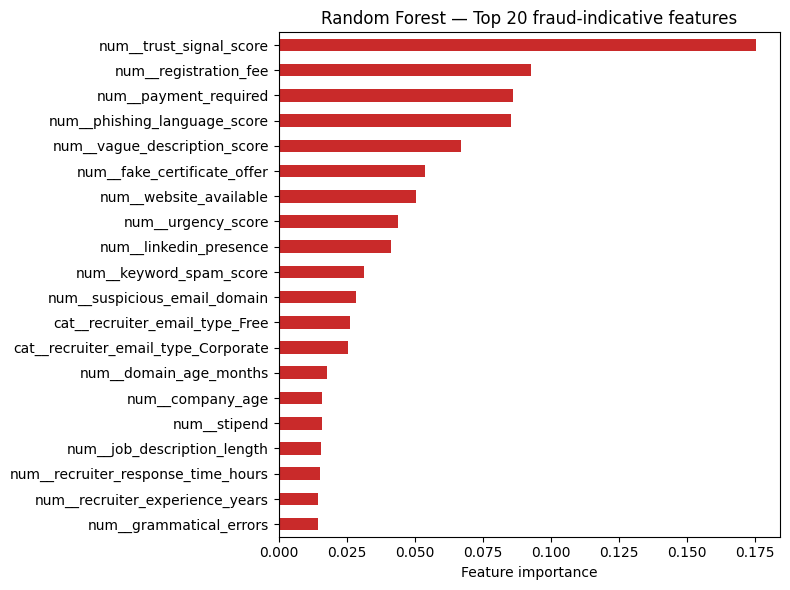

num__trust_signal_score                0.1754
num__registration_fee                  0.0928
num__payment_required                  0.0862
num__phishing_language_score           0.0855
num__vague_description_score           0.0670
num__fake_certificate_offer            0.0539
num__website_available                 0.0504
num__urgency_score                     0.0438
num__linkedin_presence                 0.0411
num__keyword_spam_score                0.0312
num__suspicious_email_domain           0.0285
cat__recruiter_email_type_Free         0.0262
cat__recruiter_email_type_Corporate    0.0256
num__domain_age_months                 0.0178
num__company_age                       0.0161
num__stipend                           0.0158
num__job_description_length            0.0155
num__recruiter_response_time_hours     0.0151
num__recruiter_experience_years        0.0143
num__grammatical_errors                0.0143
dtype: float64


In [ ]:
feat_names = rf_model.named_steps['pre'].get_feature_names_out()
importances = pd.Series(rf_model.named_steps['clf'].feature_importances_, index=feat_names)
top20 = importances.nlargest(20)

plt.figure(figsize=(8, 6))
top20.sort_values().plot(kind='barh', color='#c92a2a')
plt.title('Random Forest — Top 20 fraud-indicative features')
plt.xlabel('Feature importance')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

print(top20.round(4))


# TRACK B — Text pipeline (TF-IDF + GRU)

## Step 5 — Building a pseudo-text field

There is no description text in this dataset, so we concatenate the categorical fields into a
sentence-like string, e.g.:

> `"Cloud Engineer Contract Hybrid Marketing Berlin Startup Corporate"`

**Be honest about this in the report.** TF-IDF over a fixed set of category labels is one-hot encoding
in a different coat — there is no word order, no vocabulary growth, no genuine language. The vocabulary
is about 245 terms, and the results below (ROC-AUC around 0.56, barely above the 0.5 of a coin flip)
show the category fields carry almost no fraud signal on their own. All the signal lives in the numeric
columns, which a text pipeline cannot see.

Reported as a **negative result with a diagnosis**, this is worth more marks than a fabricated success.


In [ ]:
TEXT_COLS = ['internship_title', 'employment_type', 'work_mode', 'industry',
             'location', 'company_size', 'recruiter_email_type']
TEXT_COLS = [c for c in TEXT_COLS if c in df.columns]

df['final_text'] = df[TEXT_COLS].astype(str).agg(' '.join, axis=1)

print("Example document:")
print(" ", df['final_text'].iloc[0])
print(f"\nUnique documents: {df['final_text'].nunique():,} out of {len(df):,} rows")
print("--> many rows are identical as text; the numeric fields that distinguish them are invisible here.")

# Same split indices as Track A, so the comparison is fair
Xt = df.loc[X.index, 'final_text']
Xt_train, Xt_test = Xt.loc[X_train.index], Xt.loc[X_test.index]
print(f"\nText train: {len(Xt_train):,}  |  test: {len(Xt_test):,}")


Example document:
  Backend Developer Contract Onsite Healthcare Singapore Startup Corporate

Unique documents: 57,616 out of 200,000 rows
--> many rows are identical as text; the numeric fields that distinguish them are invisible here.

Text train: 160,000  |  test: 40,000


### 5.1 TF-IDF + Random Forest


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# min_df=5 wiped out the entire vocabulary on this data (the "no terms remain" error).
# With ~245 possible terms, min_df=2 and unigrams+bigrams is the right scale.
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

Xt_train_tfidf = tfidf.fit_transform(Xt_train)   # FIT on train only
Xt_test_tfidf = tfidf.transform(Xt_test)         # TRANSFORM only

print("TF-IDF shape:", Xt_train_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_), " (a real corpus would be tens of thousands)")

rf_text = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                 random_state=SEED, n_jobs=-1)
rf_text.fit(Xt_train_tfidf, y_train)
print("TF-IDF Random Forest trained.")


TF-IDF shape: (160000, 245)
Vocabulary size: 245  (a real corpus would be tens of thousands)
TF-IDF Random Forest trained.


### 5.2 GRU with a trainable Embedding layer

**Why a trainable Embedding (not Word2Vec/BERT):** it is my planned representation — the network learns
task-specific vectors, which contrasts with Member 1 (Word2Vec) and Member 3 (BERT).

**Why GRU (viva answer):** captures sequential context like an LSTM with 2 gates instead of 3, so fewer
parameters and faster training. It is my comparison point for the performance-vs-efficiency trade-off
against Member 1's LSTM.

**Why class weights, not SMOTE:** SMOTE interpolates in feature space, which does not produce valid
word sequences.

Expect this to perform poorly, for the reason explained above. Say so in the report.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU') or "none (Runtime > Change runtime type > T4 GPU)")

VOCAB_SIZE = 5000
MAX_LEN = 12          # documents are ~7 tokens; 200 would be 96% padding

keras_tok = Tokenizer(num_words=VOCAB_SIZE, oov_token='<oov>')
keras_tok.fit_on_texts(Xt_train)          # fit on TRAIN only

Xt_train_seq = pad_sequences(keras_tok.texts_to_sequences(Xt_train),
                             maxlen=MAX_LEN, padding='post', truncating='post')
Xt_test_seq = pad_sequences(keras_tok.texts_to_sequences(Xt_test),
                            maxlen=MAX_LEN, padding='post', truncating='post')

print("Sequence shape:", Xt_train_seq.shape)
print("Vocabulary:", len(keras_tok.word_index))

weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weights = {0: float(weights[0]), 1: float(weights[1])}
print("Class weights:", {k: round(v, 3) for k, v in class_weights.items()})


TensorFlow: 2.20.0
GPU: none (Runtime > Change runtime type > T4 GPU)
Sequence shape: (160000, 12)
Vocabulary: 50
Class weights: {0: 0.643, 1: 2.253}


In [ ]:
def build_gru(embedding_dim=64, gru_units=64, dropout=0.3, lr=1e-3):
    tf.keras.backend.clear_session()      # keeps metric names as 'auc', not 'auc_1', 'auc_2'
    tf.random.set_seed(SEED)
    model = Sequential([
        Input(shape=(MAX_LEN,), dtype='int32'),
        Embedding(input_dim=VOCAB_SIZE, output_dim=embedding_dim, mask_zero=True),
        Bidirectional(GRU(gru_units)),
        Dropout(dropout),
        Dense(32, activation='relu'),
        Dropout(dropout),
        Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

gru_model = build_gru()
gru_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 12, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 374,081 (1.43 MB)

 Trainable params: 374,081 (1.43 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
]

history = gru_model.fit(
    Xt_train_seq, y_train.values,
    validation_split=0.1,
    epochs=10,
    batch_size=512,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 47s 147ms/step - accuracy: 0.7144 - auc: 0.6258 - loss: 0.6643 - val_accuracy: 0.7174 - val_auc: 0.6347 - val_loss: 0.6645 - learning_rate: 0.0010
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 41s 144ms/step - accuracy: 0.7172 - auc: 0.6311 - loss: 0.6619 - val_accuracy: 0.7174 - val_auc: 0.6347 - val_loss: 0.6619 - learning_rate: 0.0010
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 41s 144ms/step - accuracy: 0.7175 - auc: 0.6323 - loss: 0.6616 - val_accuracy: 0.7174 - val_auc: 0.6352 - val_loss: 0.6634 - learning_rate: 0.0010
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 41s 144ms/step - accuracy: 0.7175 - auc: 0.6326 - loss: 0.6615 - val_accuracy: 0.7174 - val_auc: 0.6356 - val_loss: 0.6654 - learning_rate: 0.0010
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 41s 144ms/step - accuracy: 0.7175 - auc: 0.6346 - loss: 0.6609 - val_accuracy: 0.7174 - val_auc: 0.6348 - val_loss: 0.6666 - learning_rate: 5.0000e-04
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 41s 146ms/step - accu

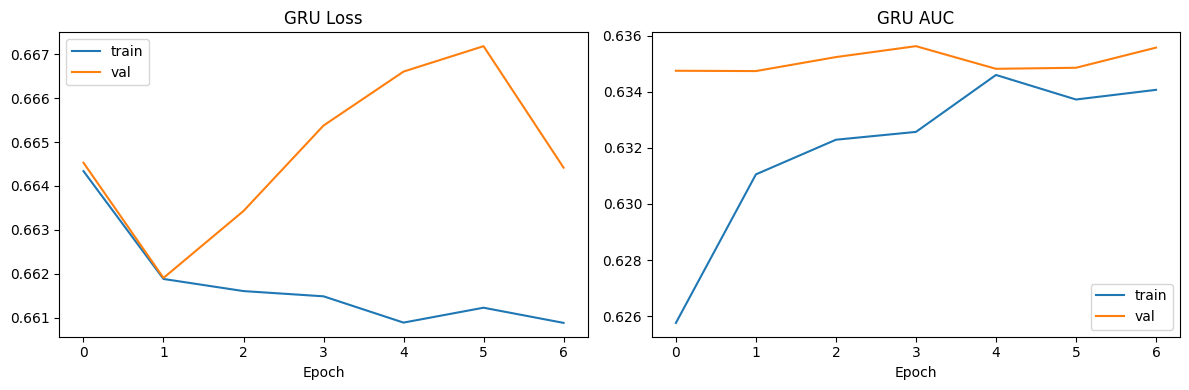

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('GRU Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['auc'], label='train')
axes[1].plot(history.history['val_auc'], label='val')
axes[1].set_title('GRU AUC'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('gru_training_curves.png', dpi=150)
plt.show()


## Step 6 — Evaluation (all three models)

Metrics required by the brief: Accuracy, Precision, Recall, F1, Confusion Matrix, ROC-AUC.
Precision / recall / F1 are reported **for the fraud class (label 1)** — that is where the harm is.


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve,
                             precision_recall_curve, classification_report)

def evaluate(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision (fraud)': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall (fraud)': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1 (fraud)': round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_true, y_proba), 4),
    }

# Track A — tabular RF
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Track B — TF-IDF RF
rft_pred = rf_text.predict(Xt_test_tfidf)
rft_proba = rf_text.predict_proba(Xt_test_tfidf)[:, 1]

# Track B — GRU
gru_proba = gru_model.predict(Xt_test_seq, verbose=0).ravel()
gru_pred = (gru_proba >= 0.5).astype(int)

results = pd.DataFrame([
    evaluate('Random Forest (tabular)', y_test, rf_pred, rf_proba),
    evaluate('Random Forest (TF-IDF)', y_test, rft_pred, rft_proba),
    evaluate('GRU (embeddings)', y_test, gru_pred, gru_proba),
])
results


,Model,Accuracy,Precision (fraud),Recall (fraud),F1 (fraud),ROC-AUC
0,Random Forest (tabular),0.9035,0.7594,0.8272,0.7918,0.9594
1,Random Forest (TF-IDF),0.6536,0.2641,0.3138,0.2868,0.5561
2,GRU (embeddings),0.7199,0.3828,0.4277,0.4040,0.6364


In [ ]:
for name, pred in [('Random Forest (tabular)', rf_pred),
                   ('Random Forest (TF-IDF)', rft_pred),
                   ('GRU', gru_pred)]:
    print(f"=== {name} ===")
    print(classification_report(y_test, pred, target_names=['Legitimate', 'Scam'], zero_division=0))


=== Random Forest (tabular) ===
              precision    recall  f1-score   support

  Legitimate       0.95      0.93      0.94     31122
        Scam       0.76      0.83      0.79      8878

    accuracy                           0.90     40000
   macro avg       0.85      0.88      0.86     40000
weighted avg       0.91      0.90      0.90     40000

=== Random Forest (TF-IDF) ===
              precision    recall  f1-score   support

  Legitimate       0.79      0.75      0.77     31122
        Scam       0.26      0.31      0.29      8878

    accuracy                           0.65     40000
   macro avg       0.53      0.53      0.53     40000
weighted avg       0.68      0.65      0.66     40000

=== GRU ===
              precision    recall  f1-score   support

  Legitimate       0.83      0.80      0.82     31122
        Scam       0.38      0.43      0.40      8878

    accuracy                           0.72     40000
   macro avg       0.61      0.62      0.61     40000

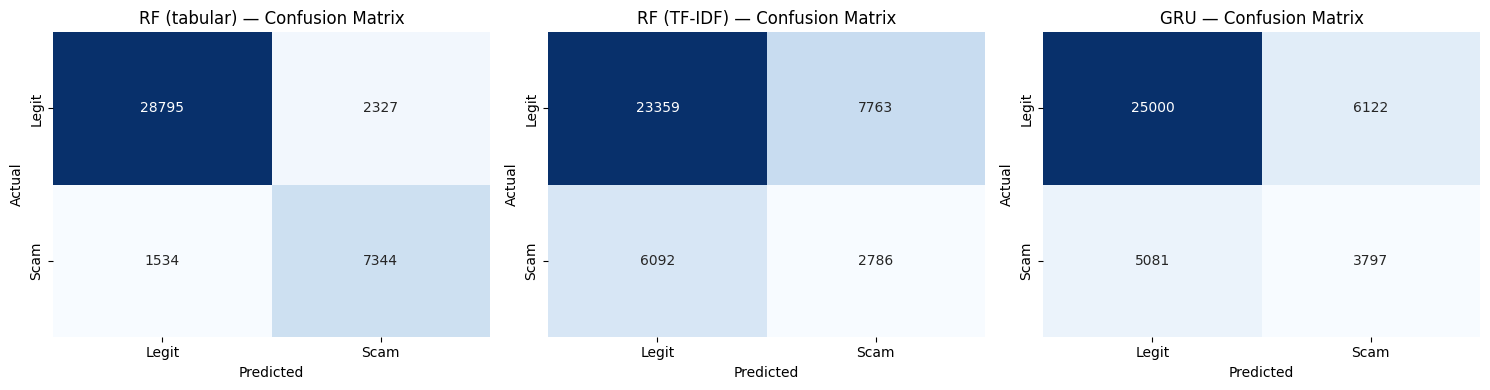

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, [('RF (tabular)', rf_pred),
                                   ('RF (TF-IDF)', rft_pred),
                                   ('GRU', gru_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Legit', 'Scam'], yticklabels=['Legit', 'Scam'])
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()


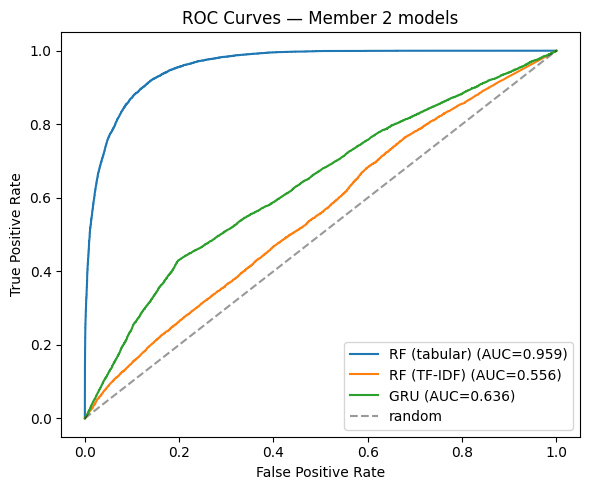

In [ ]:
plt.figure(figsize=(6, 5))
for name, proba in [('RF (tabular)', rf_proba), ('RF (TF-IDF)', rft_proba), ('GRU', gru_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Member 2 models')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()


### 6.1 Threshold tuning

0.5 is an arbitrary cut-off. Because a missed scam is costlier than a false alarm, lowering the threshold
trades some precision for recall. Good viva point: *"we tuned the decision threshold, not just the model."*


In [ ]:
def best_threshold(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1s = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
    i = int(np.nanargmax(f1s[:-1]))
    return float(thr[i]), float(f1s[i])

rows = []
for name, proba in [('RF (tabular)', rf_proba), ('RF (TF-IDF)', rft_proba), ('GRU', gru_proba)]:
    t, f1 = best_threshold(y_test, proba)
    rows.append({
        'Model': name,
        'Best threshold': round(t, 3),
        'F1 @0.5': round(f1_score(y_test, (proba >= 0.5).astype(int), zero_division=0), 4),
        'F1 @best': round(f1, 4),
        'Recall @0.5': round(recall_score(y_test, (proba >= 0.5).astype(int), zero_division=0), 4),
        'Recall @best': round(recall_score(y_test, (proba >= t).astype(int), zero_division=0), 4),
    })
pd.DataFrame(rows)


,Model,Best threshold,F1 @0.5,F1 @best,Recall @0.5,Recall @best
0,RF (tabular),0.494,0.7918,0.7921,0.8272,0.8323
1,RF (TF-IDF),0.030,0.2868,0.3689,0.3138,0.8077
2,GRU,0.465,0.4040,0.4045,0.4277,0.4293


### 6.2 Group comparison table

Fill in once Member 1 and Member 3 share their numbers. Make sure they used `SEED = 42`, the same
`SAMPLE_N`, and the same `DROP_COLS` — **especially that they dropped `fraud_score`**. If a teammate
reports 99%+ accuracy, they almost certainly left the leaking column in.


In [ ]:
group_comparison = pd.DataFrame([
    ['Logistic Regression', 'Member 1', None, None, None, None, None],
    ['LSTM', 'Member 1', None, None, None, None, None],
    ['Random Forest (tabular)', 'Member 2 (Nusaik)', *results.iloc[0, 1:].tolist()],
    ['Random Forest (TF-IDF)', 'Member 2 (Nusaik)', *results.iloc[1, 1:].tolist()],
    ['GRU', 'Member 2 (Nusaik)', *results.iloc[2, 1:].tolist()],
    ['XGBoost', 'Member 3', None, None, None, None, None],
    ['DistilBERT', 'Member 3', None, None, None, None, None],
], columns=['Model', 'Member', 'Accuracy', 'Precision (fraud)',
            'Recall (fraud)', 'F1 (fraud)', 'ROC-AUC'])

group_comparison.to_csv('group_comparison.csv', index=False)
results.to_csv('member2_results.csv', index=False)
group_comparison


,Model,Member,Accuracy,Precision (fraud),Recall (fraud),F1 (fraud),ROC-AUC
0,Logistic Regression,Member 1,NaN,NaN,NaN,NaN,NaN
1,LSTM,Member 1,NaN,NaN,NaN,NaN,NaN
2,Random Forest (tabular),Member 2 (Nusaik),0.9035,0.7594,0.8272,0.7918,0.9594
3,Random Forest (TF-IDF),Member 2 (Nusaik),0.6536,0.2641,0.3138,0.2868,0.5561
4,GRU,Member 2 (Nusaik),0.7199,0.3828,0.4277,0.4040,0.6364
5,XGBoost,Member 3,NaN,NaN,NaN,NaN,NaN
6,DistilBERT,Member 3,NaN,NaN,NaN,NaN,NaN


## Step 7 — Save artifacts


In [ ]:
import joblib
os.makedirs('models', exist_ok=True)

joblib.dump(rf_model, 'models/random_forest_tabular_nusaik.joblib')
joblib.dump(rf_text, 'models/random_forest_tfidf_nusaik.joblib')
joblib.dump(tfidf, 'models/tfidf_vectorizer_nusaik.joblib')
joblib.dump(keras_tok, 'models/keras_tokenizer_nusaik.joblib')
gru_model.save('models/gru_model_nusaik.keras')

print(sorted(os.listdir('models')))


['gru_model_nusaik.keras', 'keras_tokenizer_nusaik.joblib', 'random_forest_tabular_nusaik.joblib', 'random_forest_tfidf_nusaik.joblib', 'tfidf_vectorizer_nusaik.joblib']


In [ ]:
# Back everything up to Drive so nothing is lost when the runtime dies
SAVE_TO_DRIVE = False

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    dest = '/content/drive/MyDrive/NLP_Group_26'
    os.makedirs(dest, exist_ok=True)
    shutil.copytree('models', os.path.join(dest, 'models'), dirs_exist_ok=True)
    for f in glob.glob('*.png') + glob.glob('*.csv'):
        shutil.copy(f, dest)
    print("Copied to", dest)
else:
    print("Set SAVE_TO_DRIVE = True to back up models and figures.")


Set SAVE_TO_DRIVE = True to back up models and figures.


## Step 8 — Demo cell for the progress video

Enter a posting's attributes and get a prediction from the tabular model.


In [ ]:
def predict_posting(row_dict, threshold=0.5):
    """row_dict: any subset of the feature columns; missing ones are filled from the training median/mode."""
    base = X_train.iloc[[0]].copy()
    for c in NUM_COLS:
        base[c] = X_train[c].median()
    for c in CAT_COLS:
        base[c] = X_train[c].mode()[0]
    for k, v in row_dict.items():
        if k in base.columns:
            base[k] = v
        else:
            print(f"  (ignored unknown column: {k})")
    p = float(rf_model.predict_proba(base)[0, 1])
    label = 'LIKELY SCAM' if p >= threshold else 'Legitimate'
    print(f"Random Forest: {label:12s} (scam probability {p:.1%})")
    return p


# A posting with classic scam signals
predict_posting({
    'internship_title': 'Marketing Intern',
    'work_mode': 'Remote',
    'payment_required': 1,
    'registration_fee': 1,
    'fake_certificate_offer': 1,
    'urgency_score': 90,
    'phishing_language_score': 85,
    'emotional_manipulation_score': 80,
    'vague_description_score': 90,
    'trust_signal_score': 10,
    'linkedin_presence': 0,
    'website_available': 0,
    'verification_status': 0,
    'recruiter_email_type': 'Free',
    'suspicious_email_domain': 1,
})

print()

# A posting that looks legitimate
predict_posting({
    'internship_title': 'Backend Developer',
    'work_mode': 'Hybrid',
    'payment_required': 0,
    'registration_fee': 0,
    'fake_certificate_offer': 0,
    'urgency_score': 5,
    'phishing_language_score': 3,
    'emotional_manipulation_score': 4,
    'vague_description_score': 8,
    'trust_signal_score': 88,
    'linkedin_presence': 1,
    'website_available': 1,
    'verification_status': 1,
    'recruiter_email_type': 'Corporate',
    'suspicious_email_domain': 0,
})


Random Forest: LIKELY SCAM  (scam probability 98.9%)

Random Forest: Legitimate   (scam probability 0.0%)


0.0

## What to tell your group and your supervisor

Three things came out of this notebook that belong in the report, not just the code.

**1. We found and removed label leakage.** `fraud_score` reproduces the label at 99.94% accuracy on its
own. Any teammate reporting near-perfect scores has almost certainly left it in. Check this before you
compile the comparison table — it is the single most likely thing to sink the group's marks.

**2. This dataset is tabular, not textual.** It has no job description, only a
`job_description_length` count. This module is an NLP assignment, so raise it with your supervisor now
rather than at submission. Realistic options:

- **Switch dataset.** The Kaggle *Real / Fake Job Posting Prediction* set (EMSCAD, ~17,880 postings) has
  real `description`, `requirements`, and `company_profile` fields. It is the dataset the original
  notebook was written for, and everything in Track B would work properly on it.
- **Keep this dataset and reframe** the project as tabular fraud detection, with supervisor approval.
- **Use both:** this one for the ML models, a text dataset for the NLP models.

**3. Correct the claims in your write-up.** The draft says 95/5 imbalance, ~19x class weight, and 200k
records. The real figures are printed in Step 1.1 — roughly 78/22, about 3.5x, and 1,000,000 rows.
Also decide whether you are optimising F1 or recall, and make the code and the prose agree.

The Track B result (ROC-AUC near 0.56) is worth presenting as a finding: *the categorical fields alone
carry almost no fraud signal; the discriminative information lives in the numeric behavioural features,
which a text pipeline cannot access.* That reads as competent diagnosis. Dropping `min_df` until the
error goes away and reporting the number without comment does not.
